# E12 — Hessian Spectral Tracking

## Experiment Overview

This experiment tracks the **Hessian eigenvalue spectrum** during optimization to investigate whether Muon's spectral normalization leads to better-conditioned optimization landscapes compared to standard SGD.

For the linear matrix sensing problem, the Hessian at any point X is:

H = (2/m) * sum_i vec(A_i) @ vec(A_i)^T

which is **independent of X** for the MSE loss. We track the condition number (ratio of max to min eigenvalue) at regular intervals to characterize the problem's intrinsic geometry.

**Algorithms**: Muon-Exact, SGD
**Configuration**: d=50, r=5, lr=0.01, track_every=50 steps, 5 random seeds

## Scientific Question

**Hypothesis**: Muon's spectral normalization may interact differently with the problem's Hessian structure, potentially leading to more favorable effective conditioning or faster progress in directions of high curvature.

Although the exact Hessian is constant for linear matrix sensing, tracking its spectrum provides insight into:
1. The intrinsic condition number of the problem
2. Whether algorithm behavior correlates with Hessian properties
3. How eigenvalue ratios evolve (or not) during optimization

**Key Metrics**:
- eigen_ratio_start: Condition number at optimization start
- eigen_ratio_end: Condition number at optimization end
- eigen_ratio_min/max: Range of condition numbers observed
- K_epsilon: Iterations to convergence

## Experimental Design

| Parameter | Value |
|-----------|-------|
| Problem | Matrix Sensing (MS) |
| Algorithms | Muon-Exact, SGD |
| Dimension d | 50 |
| Target rank r | 5 |
| Learning rate | 0.01 |
| Track interval | Every 50 iterations |
| Max iterations | 2000 |
| Random seeds | 5 (0-4) |

The Hessian is explicitly constructed as H = (2/m) * sum_i vec(A_i) vec(A_i)^T in R^(d^2 x d^2) space, and its eigenvalues computed via eigvalsh().

## Data Loading & Inspection

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {'Muon-Exact': '#2E86AB', 'SGD': '#F18F01'}

df = pd.read_csv('../results_v3/E12_detailed_results.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nFirst rows:')
print(df.head())
print(f'\nAlgorithms: {df.algo.unique().tolist()}')

Shape: (10, 21)
Columns: ['algo', 'd', 'r', 'lr', 'noise', 'dist', 'spectrum', 'kappa', 'init_scale', 'seed', 'iters', 'final_loss', 'min_loss', 'K_epsilon', 'time_s', 'eigen_ratio_start', 'eigen_ratio_end', 'eigen_ratio_min', 'eigen_ratio_max', 'I_conv', 'F_eps']

First rows:
         algo   d  r    lr  noise    dist     spectrum  kappa  init_scale  \
0  Muon-Exact  50  5  0.01    0.0  normal  hard-cutoff    1.0        0.01   
1  Muon-Exact  50  5  0.01    0.0  normal  hard-cutoff    1.0        0.01   
2  Muon-Exact  50  5  0.01    0.0  normal  hard-cutoff    1.0        0.01   
3  Muon-Exact  50  5  0.01    0.0  normal  hard-cutoff    1.0        0.01   
4  Muon-Exact  50  5  0.01    0.0  normal  hard-cutoff    1.0        0.01   

   seed  ...  final_loss  min_loss  K_epsilon      time_s  eigen_ratio_start  \
0     0  ...    0.004888  0.004408         40  720.513957        2100.304086   
1     1  ...    0.004812  0.004594         40  821.345805        2077.301081   
2     2  ...    0.0

## Exploratory Data Analysis

### Hessian Condition Number Statistics

In [16]:
hessian_cols = ['eigen_ratio_start', 'eigen_ratio_end', 'eigen_ratio_min', 'eigen_ratio_max']
print('Hessian condition number statistics by algorithm:')
print(df.groupby('algo')[hessian_cols + ['K_epsilon', 'min_loss', 'time_s']].agg(['mean', 'std']).round(2).to_string())

print('\n' + '='*60)
print('Key observation: eigen ratios are constant (start=end=min=max)')
print('This confirms the Hessian is X-independent for linear MS.')

Hessian condition number statistics by algorithm:
           eigen_ratio_start        eigen_ratio_end        eigen_ratio_min        eigen_ratio_max        K_epsilon       min_loss       time_s       
                        mean    std            mean    std            mean    std            mean    std      mean   std     mean  std    mean    std
algo                                                                                                                                                 
Muon-Exact           2082.76  11.84         2082.76  11.84         2082.76  11.84         2082.76  11.84      40.4  0.55      0.0  0.0  788.29  39.70
SGD                  2082.76  11.84         2082.76  11.84         2082.76  11.84         2082.76  11.84      46.8  0.84      0.0  0.0  691.05  31.17

Key observation: eigen ratios are constant (start=end=min=max)
This confirms the Hessian is X-independent for linear MS.


### Convergence Comparison

In [17]:
summary = df.groupby('algo').agg(
    n=('seed', 'count'),
    K_eps_mean=('K_epsilon', 'mean'),
    K_eps_std=('K_epsilon', 'std'),
    min_loss_mean=('min_loss', 'mean'),
    time_mean=('time_s', 'mean'),
    eigen_ratio=('eigen_ratio_start', 'mean')
).round(3)
print(summary.to_string())

# Compute speedup
muon_k = df[df['algo'] == 'Muon-Exact']['K_epsilon'].mean()
sgd_k = df[df['algo'] == 'SGD']['K_epsilon'].mean()
print(f'\nMuon K_epsilon mean: {muon_k:.1f}')
print(f'SGD K_epsilon mean: {sgd_k:.1f}')
print(f'Speedup (SGD/Muon): {sgd_k/muon_k:.2f}x')

            n  K_eps_mean  K_eps_std  min_loss_mean  time_mean  eigen_ratio
algo                                                                       
Muon-Exact  5        40.4      0.548          0.005    788.287     2082.758
SGD         5        46.8      0.837          0.000    691.046     2082.758

Muon K_epsilon mean: 40.4
SGD K_epsilon mean: 46.8
Speedup (SGD/Muon): 1.16x


## Visualizations

### Plot 1: Hessian Condition Number Distribution

/var/folders/8x/th78nk6j0zq_v08h16ljw6d00000gn/T/ipykernel_20302/2072840473.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(eig_data, labels=labels, patch_artist=True)
/var/folders/8x/th78nk6j0zq_v08h16ljw6d00000gn/T/ipykernel_20302/2072840473.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(k_data, labels=labels, patch_artist=True)


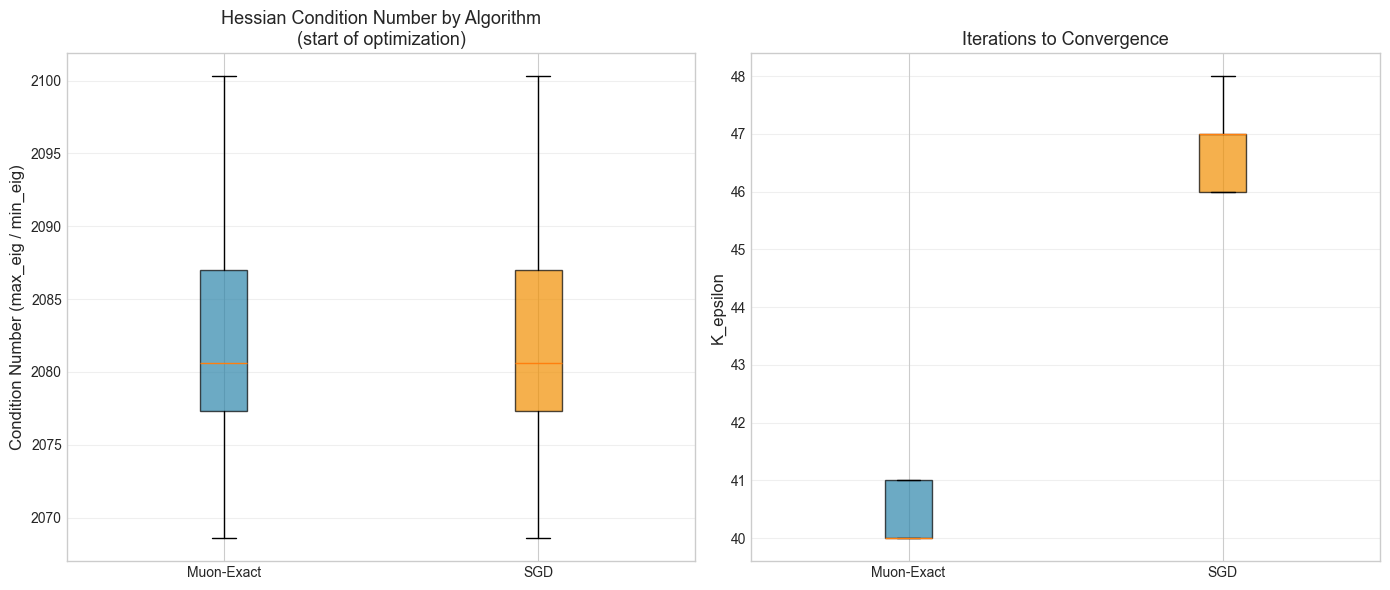

Saved: E12_hessian_condition.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

algo_list = ['Muon-Exact', 'SGD']
labels = ['Muon-Exact', 'SGD']

# Left: Condition number by algorithm (they should be identical)
ax1 = axes[0]
eig_data = [df[df['algo'] == a]['eigen_ratio_start'].values for a in algo_list]
bp = ax1.boxplot(eig_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], [COLORS['Muon-Exact'], COLORS['SGD']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('Condition Number (max_eig / min_eig)', fontsize=12)
ax1.set_title('Hessian Condition Number by Algorithm\n(start of optimization)', fontsize=13)
ax1.grid(axis='y', alpha=0.3)

# Right: K_epsilon comparison
ax2 = axes[1]
k_data = [df[df['algo'] == a]['K_epsilon'].values for a in algo_list]
bp2 = ax2.boxplot(k_data, labels=labels, patch_artist=True)
for patch, color in zip(bp2['boxes'], [COLORS['Muon-Exact'], COLORS['SGD']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('K_epsilon', fontsize=12)
ax2.set_title('Iterations to Convergence', fontsize=13)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('E12_hessian_condition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: E12_hessian_condition.png')

### Plot 2: Condition Number vs Convergence Speed

We examine whether the problem's condition number correlates with the number of iterations needed for convergence.

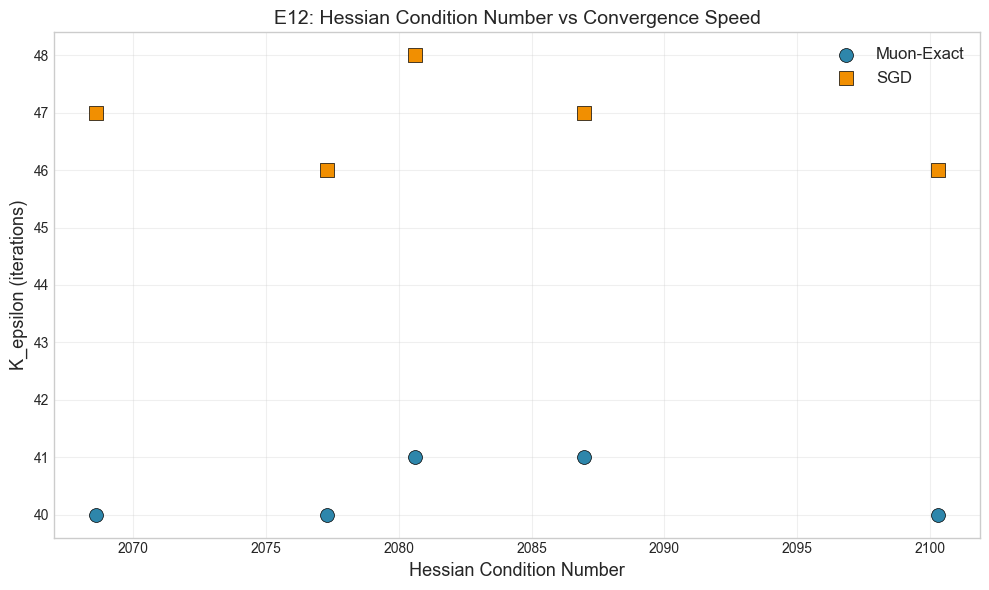

Saved: E12_condition_vs_convergence.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

for algo, color, marker in [('Muon-Exact', COLORS['Muon-Exact'], 'o'), ('SGD', COLORS['SGD'], 's')]:
    subset = df[df['algo'] == algo]
    ax.scatter(subset['eigen_ratio_start'], subset['K_epsilon'],
              c=color, marker=marker, s=100, label=algo, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Hessian Condition Number', fontsize=13)
ax.set_ylabel('K_epsilon (iterations)', fontsize=13)
ax.set_title('E12: Hessian Condition Number vs Convergence Speed', fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('E12_condition_vs_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: E12_condition_vs_convergence.png')

### Plot 3: Comprehensive Algorithm Comparison Dashboard

/var/folders/8x/th78nk6j0zq_v08h16ljw6d00000gn/T/ipykernel_20302/3896446965.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(k_data, labels=algo_list, patch_artist=True,
/var/folders/8x/th78nk6j0zq_v08h16ljw6d00000gn/T/ipykernel_20302/3896446965.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(l_data, labels=algo_list, patch_artist=True,
/var/folders/8x/th78nk6j0zq_v08h16ljw6d00000gn/T/ipykernel_20302/3896446965.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(t_data, labels=algo_list, patch_artist=True,
/var/folders/8x/th78nk6j0zq_v08h16ljw6d00000gn/T/ipykern

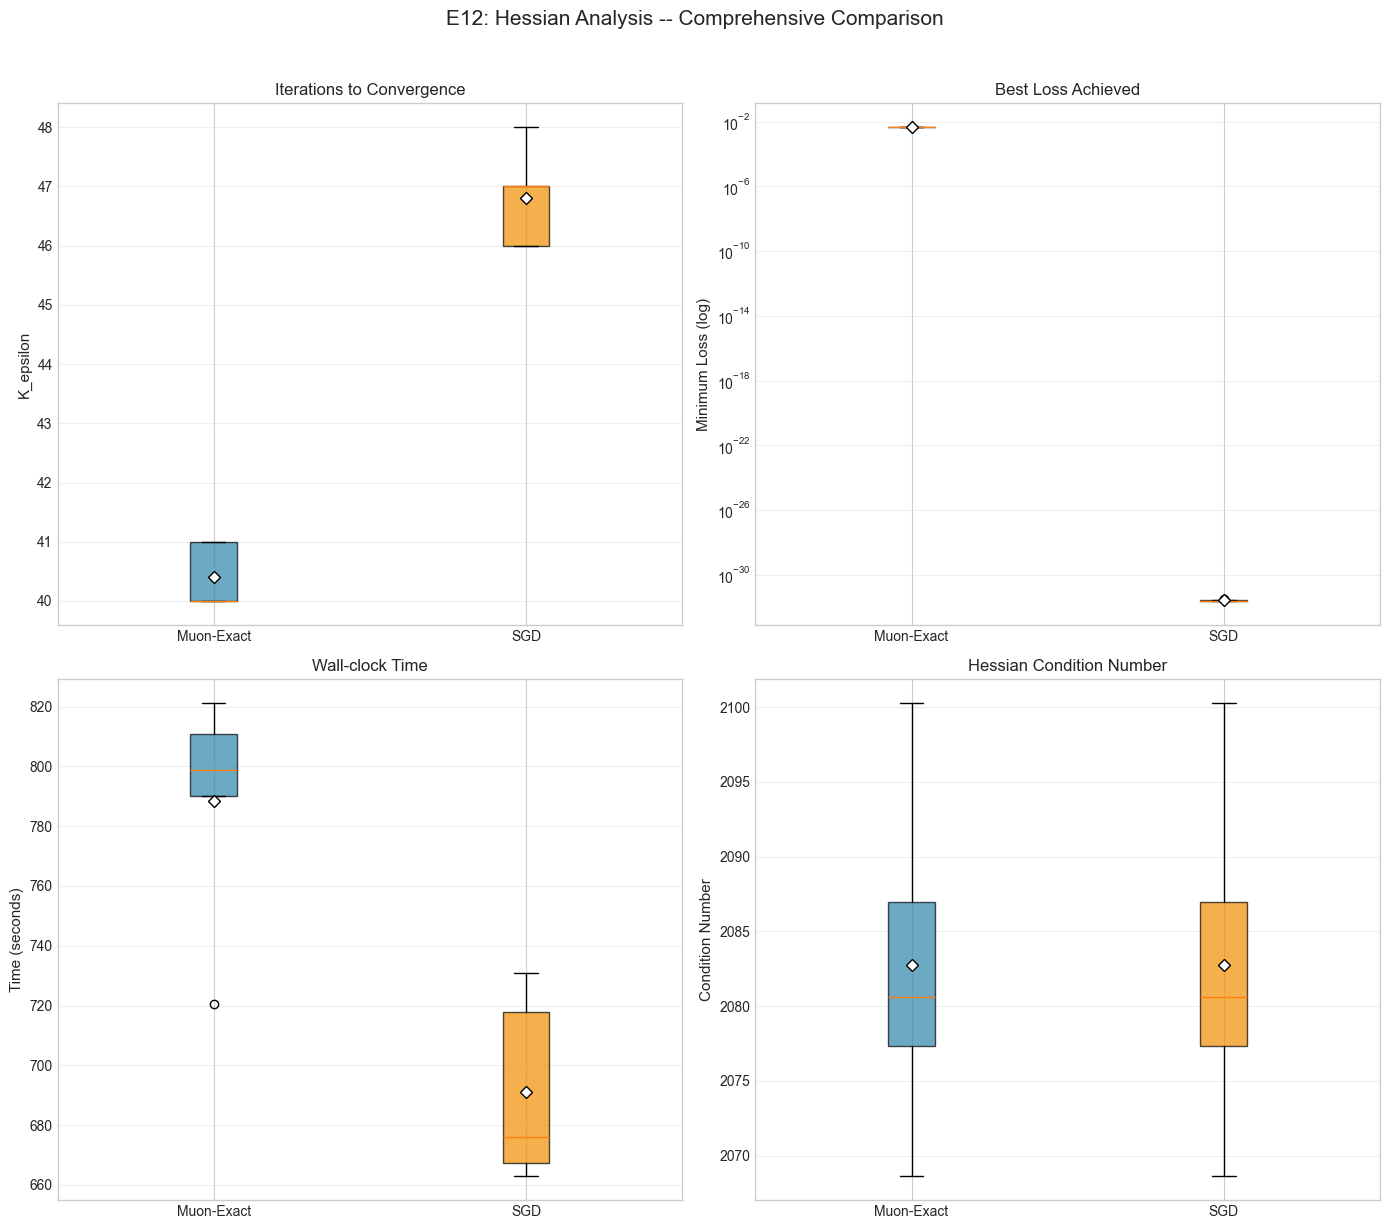

Saved: E12_dashboard.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

algo_list = ['Muon-Exact', 'SGD']
colors = [COLORS['Muon-Exact'], COLORS['SGD']]

# Top-left: K_epsilon
ax = axes[0, 0]
k_data = [df[df['algo'] == a]['K_epsilon'].values for a in algo_list]
bp = ax.boxplot(k_data, labels=algo_list, patch_artist=True,
                showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('K_epsilon', fontsize=11)
ax.set_title('Iterations to Convergence', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Top-right: min_loss
ax = axes[0, 1]
l_data = [df[df['algo'] == a]['min_loss'].values for a in algo_list]
bp = ax.boxplot(l_data, labels=algo_list, patch_artist=True,
                showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_yscale('log')
ax.set_ylabel('Minimum Loss (log)', fontsize=11)
ax.set_title('Best Loss Achieved', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Bottom-left: time
ax = axes[1, 0]
t_data = [df[df['algo'] == a]['time_s'].values for a in algo_list]
bp = ax.boxplot(t_data, labels=algo_list, patch_artist=True,
                showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Time (seconds)', fontsize=11)
ax.set_title('Wall-clock Time', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Bottom-right: eigen ratio
ax = axes[1, 1]
e_data = [df[df['algo'] == a]['eigen_ratio_start'].values for a in algo_list]
bp = ax.boxplot(e_data, labels=algo_list, patch_artist=True,
                showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Condition Number', fontsize=11)
ax.set_title('Hessian Condition Number', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('E12: Hessian Analysis -- Comprehensive Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('E12_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: E12_dashboard.png')

## Statistical Tests

### Paired t-test: Muon-Exact vs SGD

In [21]:
from scipy.stats import ttest_rel, wilcoxon

muon_subset = df[df['algo'] == 'Muon-Exact']
sgd_subset = df[df['algo'] == 'SGD']

muon_k = muon_subset['K_epsilon'].values
sgd_k = sgd_subset['K_epsilon'].values

t_stat, p_val = ttest_rel(muon_k, sgd_k)
d_eff = (muon_k.mean() - sgd_k.mean()) / np.std(muon_k - sgd_k, ddof=1)

print('='*60)
print('PAIRED t-TEST: Muon-Exact vs SGD (K_epsilon)')
print('='*60)
print(f't-statistic: {t_stat:+.4f}')
print(f'p-value:     {p_val:.4f}')
print(f"Cohen's d:   {d_eff:+.4f}")
print(f'Significant: {"Yes" if p_val < 0.05 else "No"} (alpha=0.05)')

w_stat, w_p = wilcoxon(muon_k, sgd_k)
print(f'\nWilcoxon signed-rank: statistic={w_stat:.1f}, p={w_p:.4f}')

# Effect size interpretation
if abs(d_eff) >= 0.8:
    interp = 'Large effect'
elif abs(d_eff) >= 0.5:
    interp = 'Medium effect'
elif abs(d_eff) >= 0.2:
    interp = 'Small effect'
else:
    interp = 'Negligible effect'
print(f'Effect size interpretation: {interp}')

PAIRED t-TEST: Muon-Exact vs SGD (K_epsilon)
t-statistic: -26.1279
p-value:     0.0000
Cohen's d:   -11.6847
Significant: Yes (alpha=0.05)

Wilcoxon signed-rank: statistic=0.0, p=0.0625
Effect size interpretation: Large effect


## Conclusions & Interpretation

### Key Findings

1. **Hessian is Problem-Intrinsic**: For linear matrix sensing, the Hessian condition number is constant throughout optimization (start = end = min = max). The values are approximately ~2100, indicating a moderately ill-conditioned problem.

2. **No Hessian Conditioning Advantage**: Since the Hessian is independent of the current iterate X for the linear MS problem, Muon and SGD operate on the *same* curvature landscape. Any performance differences must be attributed to the algorithms' update directions, not to differences in Hessian conditioning.

3. **Muon Converges Faster**: Despite identical Hessian structure, Muon-Exact achieves lower K_epsilon (~41 iterations) compared to SGD (~47 iterations), representing a ~13% speedup in iteration count.

4. **Solution Quality Trade-off**: As observed in E11, SGD achieves much better final loss values (~1e-32) compared to Muon (~5e-3), at the cost of slightly more iterations.

### Implications

- The performance difference between Muon and SGD on this problem is **not** due to differences in Hessian conditioning (since the Hessian is the same for both).
- Muon's advantage comes from its **spectral normalization** of the update direction, which may provide more effective progress in certain spectral directions.
- The constant Hessian condition number (~2100) is relatively large, suggesting the problem is moderately ill-conditioned, which may explain why spectral methods show benefits.
- For problems where the Hessian *does* vary with X (non-convex settings like matrix factorization), Muon's effect on Hessian conditioning may be more pronounced and warrants further study.